In [78]:
import pandas as pd
import numpy as np
import sklearn.preprocessing as preprocess
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import geopandas as gpd

In [57]:
df = pd.read_csv('jhu_csse_covid_19_timeseries_merged.csv')
df.head(10)

,uid,fips,iso2,iso3,code3,admin2,latitude,longitude,province_state,country_region,date,confirmed,deaths,recovered
0,16.0,60.0,AS,ASM,16.0,NaN,-14.271000,-170.132000,American Samoa,US,2020-01-22,0,0,NaN
1,316.0,66.0,GU,GUM,316.0,NaN,13.444300,144.793700,Guam,US,2020-01-22,0,0,NaN
2,580.0,69.0,MP,MNP,580.0,NaN,15.097900,145.673900,Northern Mariana Islands,US,2020-01-22,0,0,NaN
3,630.0,72.0,PR,PRI,630.0,NaN,18.220800,-66.590100,Puerto Rico,US,2020-01-22,0,0,NaN
4,850.0,78.0,VI,VIR,850.0,NaN,18.335800,-64.896300,Virgin Islands,US,2020-01-22,0,0,NaN
5,84001001.0,1001.0,US,USA,840.0,Autauga,32.539527,-86.644082,Alabama,US,2020-01-22,0,0,NaN
6,84001003.0,1003.0,US,USA,840.0,Baldwin,30.727750,-87.722071,Alabama,US,2020-01-22,0,0,NaN
7,84001005.0,1005.0,US,USA,840.0,Barbour,31.868263,-85.387129,Alabama,US,2020-01-22,0,0,NaN
8,84001009.0,1009.0,US,USA,840.0,Blount,33.982109,-86.567906,Alabama,US,2020-01-22,0,0,NaN
9,84001011.0,1011.0,US,USA,840.0,Bullock,32.100305,-85.712655,Alabama,US,2020-01-22,0,0,NaN


# Preprocessing

In [58]:
df.isnull().sum()

uid                30573
fips               31863
iso2               30573
iso3               30573
code3              30573
admin2             31476
latitude           13932
longitude          13932
province_state     22575
country_region         0
date                   0
confirmed              0
deaths                 0
recovered         420024
dtype: int64

In [59]:
df['country_region'].value_counts()

country_region
US                420153
China               3741
France              1419
United Kingdom      1290
Australia           1032
                   ...  
Guyana               129
Haiti                129
Holy See             129
Honduras             129
Lesotho              129
Name: count, Length: 177, dtype: int64

In [60]:
"""We will only be working with the US as our country region since we have mostly only data from the US"""
df = df[df['country_region'] == 'US']

In [61]:
"""The recovered column has too many missing values therefore we should drop it, plus it also appears to be irrelevant to our time series analysis"""
df = df.drop(columns='recovered')
df.head()

,uid,fips,iso2,iso3,code3,admin2,latitude,longitude,province_state,country_region,date,confirmed,deaths
0,16.0,60.0,AS,ASM,16.0,NaN,-14.2710,-170.1320,American Samoa,US,2020-01-22,0,0
1,316.0,66.0,GU,GUM,316.0,NaN,13.4443,144.7937,Guam,US,2020-01-22,0,0
2,580.0,69.0,MP,MNP,580.0,NaN,15.0979,145.6739,Northern Mariana Islands,US,2020-01-22,0,0
3,630.0,72.0,PR,PRI,630.0,NaN,18.2208,-66.5901,Puerto Rico,US,2020-01-22,0,0
4,850.0,78.0,VI,VIR,850.0,NaN,18.3358,-64.8963,Virgin Islands,US,2020-01-22,0,0


In [62]:
df.dtypes

uid               float64
fips              float64
iso2               object
iso3               object
code3             float64
admin2             object
latitude          float64
longitude         float64
province_state     object
country_region     object
date               object
confirmed           int64
deaths              int64
dtype: object

In [63]:
numerical_columms = [
    column for column in df.columns
    if df[column].dtype in ["int64", "float64"]
]

In [64]:
"""We only have aprox 4 months worth of data so we will only be able to predict a month or two"""
print(df['date'].max())
print(df['date'].min())

2020-05-29
2020-01-22


In [65]:
df.isnull().sum()

uid                 129
fips               1419
iso2                129
iso3                129
code3               129
admin2             1032
latitude          13674
longitude         13674
province_state      129
country_region        0
date                  0
confirmed             0
deaths                0
dtype: int64

In [66]:
df = df.dropna()
df.shape


(404673, 13)

In [76]:
def count_confirmed_only(df):
    return df[(df['confirmed'] == 1) & (df['deaths'] == 0)].shape[0]

count = count_confirmed_only(df)
print("Rows with a COVID confirmed case but there was no death:", count)


Rows with a COVID confirmed case but there was no death: 19631


# Data Visuals

/var/folders/by/6cn15l89141d0kh0p2_rt6r00000gn/T/ipykernel_22783/2987029866.py:1: MatplotlibDeprecationWarning:

The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.



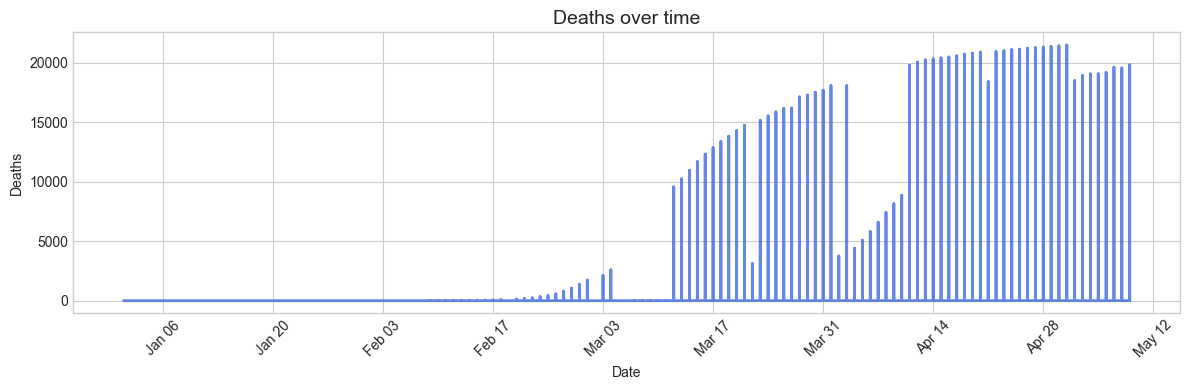

In [67]:
plt.style.use('seaborn-whitegrid')
fig, ax = plt.subplots(figsize=(12, 4)) 
ax.plot(df['date'], df['deaths'], color='royalblue', linewidth=2, alpha=0.8)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)
ax.set_xlabel('Date')
ax.set_ylabel('Deaths')
ax.set_title('Deaths over time', fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/by/6cn15l89141d0kh0p2_rt6r00000gn/T/ipykernel_22783/2886425961.py:3: MatplotlibDeprecationWarning:

The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.



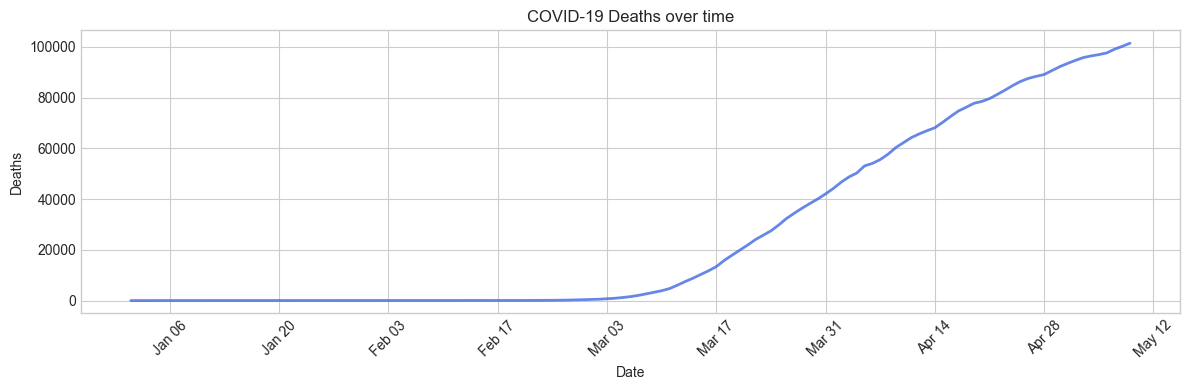

In [68]:
df_grouped = df.groupby('date')['deaths'].sum().reset_index()
df_grouped = df_grouped.sort_values('date')
plt.style.use('seaborn-whitegrid')
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_grouped['date'], df_grouped['deaths'], color='royalblue', linewidth=2, alpha=0.8)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)
ax.set_xlabel('Date')
ax.set_ylabel('Deaths')
ax.set_title('COVID-19 Deaths over time')
plt.tight_layout()
plt.show()

In [69]:
df.columns

Index(['uid', 'fips', 'iso2', 'iso3', 'code3', 'admin2', 'latitude',
       'longitude', 'province_state', 'country_region', 'date', 'confirmed',
       'deaths'],
      dtype='object')

<Axes: >

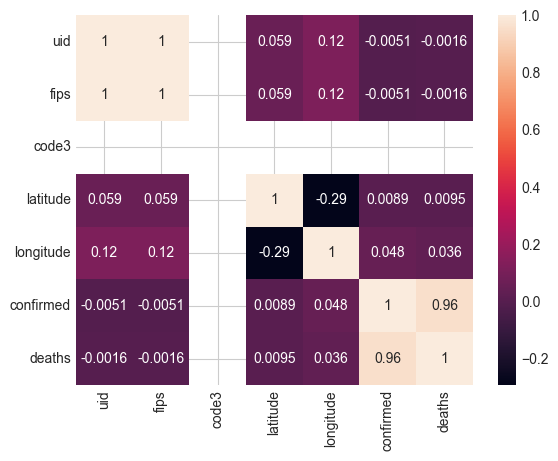

In [74]:
cols = ['uid', 'fips', 'code3', 'latitude', 'longitude', 'confirmed', 'deaths']
df_corr = df[cols]
df_corr = df_corr.corr()
sns.heatmap(df_corr, annot=True)

df_filtered = df[df['deaths'] > 1]

fig = px.scatter_geo(df_filtered,
    lat='latitude',
    lon='longitude',
    size='deaths',
    color='deaths',
    scope='usa',
    title='Daily COVID Deaths by Location (Only >1)',
    color_continuous_scale='Reds',
    opacity=0.6
)

fig.update_layout(geo=dict(showland=True, landcolor='lightgray'))
fig.show()